<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary

In [16]:
text_sequence = """“Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.”"""

In [17]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#hyperparameters
lr = 0.01
epochs = 30
input_lengths = [10,20,30]
hidden_size = 100

device

device(type='cuda', index=0)

In [18]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text_sequence)}")
sorted_text = list(sorted(set(text_sequence)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 2393
Total Unique Characters: 47
['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '“', '”']
{0: '\n', 1: ' ', 2: "'", 3: '(', 4: ')', 5: ',', 6: '-', 7: '.', 8: 'A', 9: 'D', 10: 'I', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'R', 17: 'S', 18: 'T', 19: 'a', 20: 'b', 21: 'c', 22: 'd', 23: 'e', 24: 'f', 25: 'g', 26: 'h', 27: 'i', 28: 'j', 29: 'k', 30: 'l', 31: 'm', 32: 'n', 33: 'o', 34: 'p', 35: 'q', 36: 'r', 37: 's', 38: 't', 39: 'u', 40: 'v', 41: 'w', 42: 'x', 43: 'y', 44: 'z', 45: '“', 46: '”'}


In [19]:
#Create Model
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.rnn = nn.RNN(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)


  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.rnn(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(LSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(GRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.fc1(output[:, -1, :])
    return output

In [20]:
#Splitting into train and test datasets
from sklearn.model_selection import train_test_split
def preprocess_text(text, sequence_length):
    # Preparing the dataset
    max_length = sequence_length  # Maximum length of input sequences
    X = []
    y = []
    for i in range(len(text) - max_length):
        sequence = text[i:i + max_length]
        label = text[i + max_length]
        X.append([char_to_ix[char] for char in sequence])
        y.append(char_to_ix[label])

    X = np.array(X)
    y = np.array(y)

    # Splitting the dataset into training and validation sets
    return train_test_split(X, y, test_size=0.2, random_state=1)

In [21]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [22]:
def createMODELandLOSS(model):
  model = model.upper()
  valid_models = {'RNN', 'LSTM', 'GRU'}
  if model not in valid_models:
    raise ValueError(f"Invalid Type {model}. Expected one of {valid_models}")
  if(model == "RNN"):
    model = RNN(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "LSTM"):
    model = LSTM(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "GRU"):
    model = GRU(len(sorted_text), hidden_size, len(sorted_text)).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = lr)
  return model, criterion, optimizer

In [27]:
def run(modelName):
##Data Preprocessing and converting to tensor
  for i, input_length in enumerate(input_lengths):
    model, criterion, optimizer = createMODELandLOSS(modelName)

    X_train, X_val, y_train, y_val = preprocess_text(text_sequence, input_length)

    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val = torch.tensor(X_val, dtype=torch.long).to(device)
    y_val = torch.tensor(y_val, dtype=torch.long).to(device)





    ###This is where training begins
    #Lists for storing loss and validation values
    train_loss_list = []
    val_loss_list = []
    val_accuracy_list = []


    #Create a new training loop for each input_length
    for epoch in range(epochs):
      model.train()

      optimizer.zero_grad()
      y_pred = model(X_train)  # Forward pass
      loss = criterion(y_pred, y_train)  # Compute loss
      loss.backward()  # Backward pass
      optimizer.step()  # Update model parameters

      train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                          #to the training loss list (of all epochs)


      #Here is where we evaluate the model on the current epoch
      model.eval()
      with torch.no_grad():
        val_output = model(X_val) # Take test dataset and run it through this epoch's model

        val_loss = criterion(val_output, y_val) #Find the loss

        _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

        val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                          #compare it to the ground truth, and find how accurate we are

        val_loss_list.append(val_loss.item())
        val_accuracy_list.append(val_accuracy.item())


        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')

    createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
    print(summary(model, input_size = (1,20), dtypes=[torch.long]))



Epoch 0, Loss: 3.8490, Val Accuracy: 0.2537, Val Loss: 3.3114
Epoch 1, Loss: 3.2987, Val Accuracy: 0.2642, Val Loss: 2.8665
Epoch 2, Loss: 2.8500, Val Accuracy: 0.2767, Val Loss: 2.6564
Epoch 3, Loss: 2.6338, Val Accuracy: 0.3145, Val Loss: 2.5506
Epoch 4, Loss: 2.4900, Val Accuracy: 0.3459, Val Loss: 2.4686
Epoch 5, Loss: 2.3851, Val Accuracy: 0.3795, Val Loss: 2.3870
Epoch 6, Loss: 2.2989, Val Accuracy: 0.4382, Val Loss: 2.3173
Epoch 7, Loss: 2.2244, Val Accuracy: 0.4298, Val Loss: 2.2645
Epoch 8, Loss: 2.1568, Val Accuracy: 0.4319, Val Loss: 2.2263
Epoch 9, Loss: 2.0932, Val Accuracy: 0.4298, Val Loss: 2.1990
Epoch 10, Loss: 2.0336, Val Accuracy: 0.4298, Val Loss: 2.1757
Epoch 11, Loss: 1.9768, Val Accuracy: 0.4486, Val Loss: 2.1509
Epoch 12, Loss: 1.9217, Val Accuracy: 0.4486, Val Loss: 2.1220
Epoch 13, Loss: 1.8680, Val Accuracy: 0.4612, Val Loss: 2.0902
Epoch 14, Loss: 1.8154, Val Accuracy: 0.4759, Val Loss: 2.0575
Epoch 15, Loss: 1.7642, Val Accuracy: 0.4759, Val Loss: 2.0262
Ep

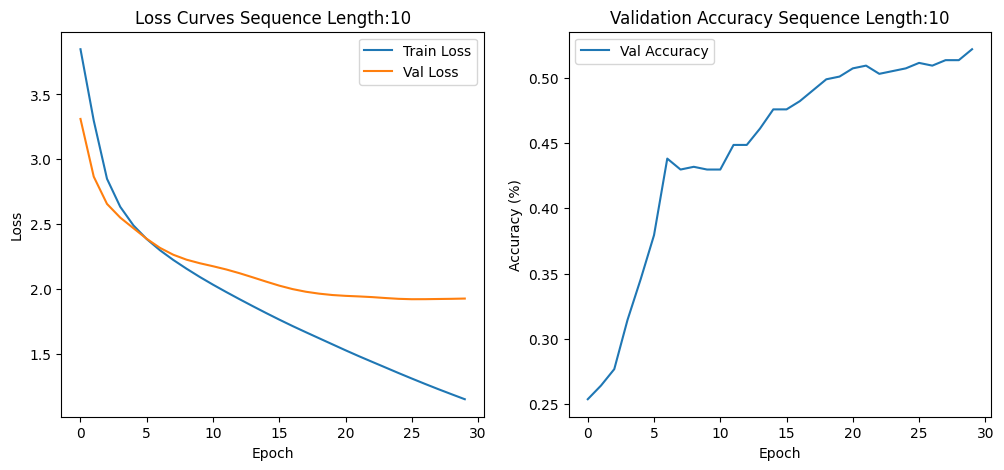

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.12
Estimated Total Size (MB): 0.15
Epoch 0, Loss: 3.8677, Val Accuracy: 0.2695, Val Loss: 3.3541
Epoch 1, Loss: 3.3223, Val Accuracy: 0.2863, Val Loss: 2.8983
Epoch 2, Loss: 2.8388, Val Accuracy: 0.2842, Val Loss: 2.7277
Epoch 3, Loss: 2.6362, Val Accuracy: 0.2779, Val Loss: 2.6457
Epoch 4, Loss: 2.5010, Val Accuracy: 0.3032, Val Loss: 2.5799
Epoch 5, Loss: 2.3964, Val Accuracy: 0.3179, Val Loss: 2.5240
Epoch 6, Loss: 2.3125, Val Accuracy: 0

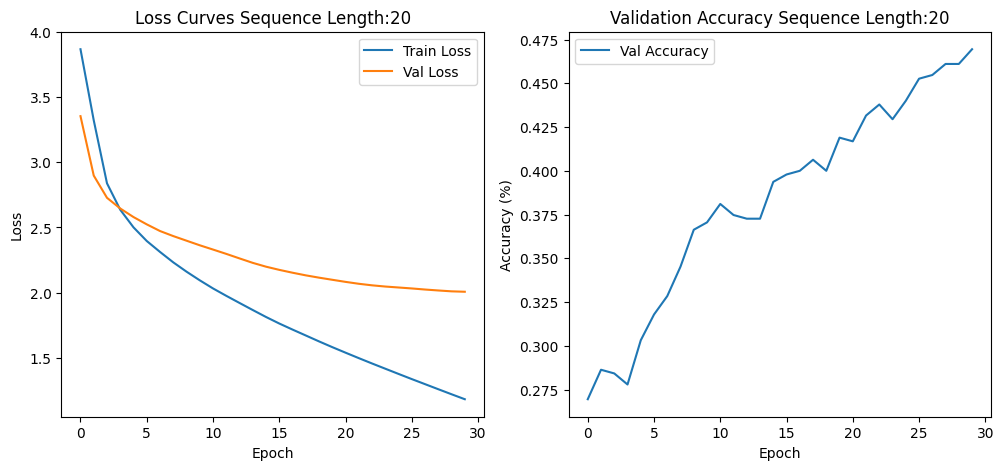

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.12
Estimated Total Size (MB): 0.15
Epoch 0, Loss: 3.9052, Val Accuracy: 0.2283, Val Loss: 3.3963
Epoch 1, Loss: 3.3581, Val Accuracy: 0.2347, Val Loss: 2.9622
Epoch 2, Loss: 2.8756, Val Accuracy: 0.2093, Val Loss: 2.7863
Epoch 3, Loss: 2.6668, Val Accuracy: 0.2347, Val Loss: 2.6857
Epoch 4, Loss: 2.5287, Val Accuracy: 0.2558, Val Loss: 2.6107
Epoch 5, Loss: 2.4328, Val Accuracy: 0.2896, Val Loss: 2.5517
Epoch 6, Loss: 2.3557, Val Accuracy: 0

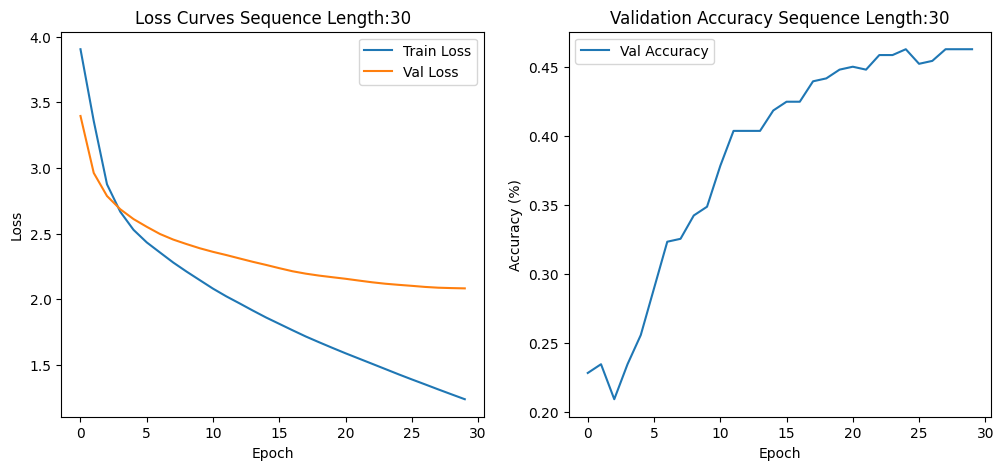

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.12
Estimated Total Size (MB): 0.15


In [28]:
run("RNN")

Epoch 0, Loss: 3.8668, Val Accuracy: 0.1405, Val Loss: 3.6306
Epoch 1, Loss: 3.6145, Val Accuracy: 0.2075, Val Loss: 3.2721
Epoch 2, Loss: 3.2484, Val Accuracy: 0.2285, Val Loss: 2.9814
Epoch 3, Loss: 2.9578, Val Accuracy: 0.2159, Val Loss: 2.8579
Epoch 4, Loss: 2.8617, Val Accuracy: 0.2516, Val Loss: 2.7203
Epoch 5, Loss: 2.7391, Val Accuracy: 0.2830, Val Loss: 2.6164
Epoch 6, Loss: 2.6239, Val Accuracy: 0.3145, Val Loss: 2.5451
Epoch 7, Loss: 2.5350, Val Accuracy: 0.3145, Val Loss: 2.4808
Epoch 8, Loss: 2.4550, Val Accuracy: 0.3480, Val Loss: 2.4194
Epoch 9, Loss: 2.3791, Val Accuracy: 0.3669, Val Loss: 2.3624
Epoch 10, Loss: 2.3074, Val Accuracy: 0.3795, Val Loss: 2.3106
Epoch 11, Loss: 2.2399, Val Accuracy: 0.3983, Val Loss: 2.2629
Epoch 12, Loss: 2.1757, Val Accuracy: 0.4109, Val Loss: 2.2172
Epoch 13, Loss: 2.1134, Val Accuracy: 0.4109, Val Loss: 2.1760
Epoch 14, Loss: 2.0534, Val Accuracy: 0.4193, Val Loss: 2.1415
Epoch 15, Loss: 1.9963, Val Accuracy: 0.4235, Val Loss: 2.1125
Ep

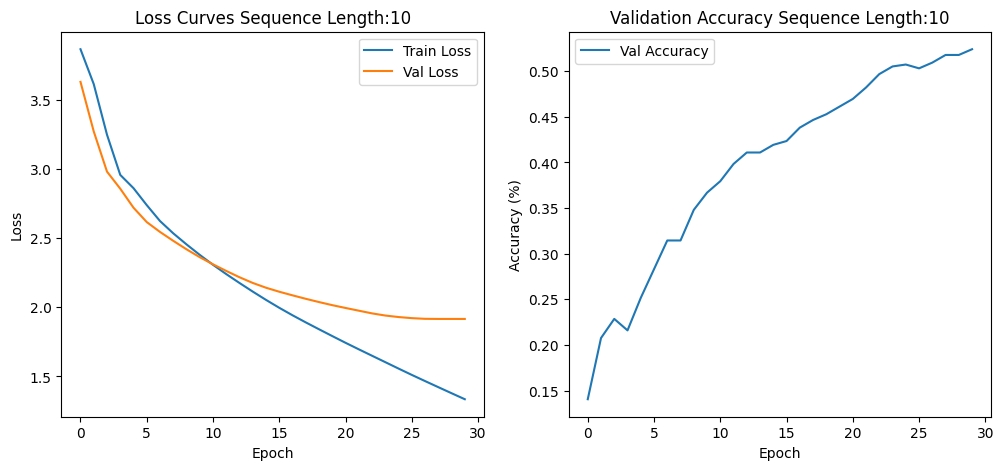

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─LSTM: 1-2                              [1, 20, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.63
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.36
Estimated Total Size (MB): 0.39
Epoch 0, Loss: 3.8774, Val Accuracy: 0.2442, Val Loss: 3.6220
Epoch 1, Loss: 3.6210, Val Accuracy: 0.1874, Val Loss: 3.2413
Epoch 2, Loss: 3.2340, Val Accuracy: 0.1495, Val Loss: 2.9860
Epoch 3, Loss: 2.9589, Val Accuracy: 0.2211, Val Loss: 2.9458
Epoch 4, Loss: 2.8718, Val Accuracy: 0.2758, Val Loss: 2.8563
Epoch 5, Loss: 2.7520, Val Accuracy: 0.2632, Val Loss: 2.7631
Epoch 6, Loss: 2.6420, Val Accuracy: 0

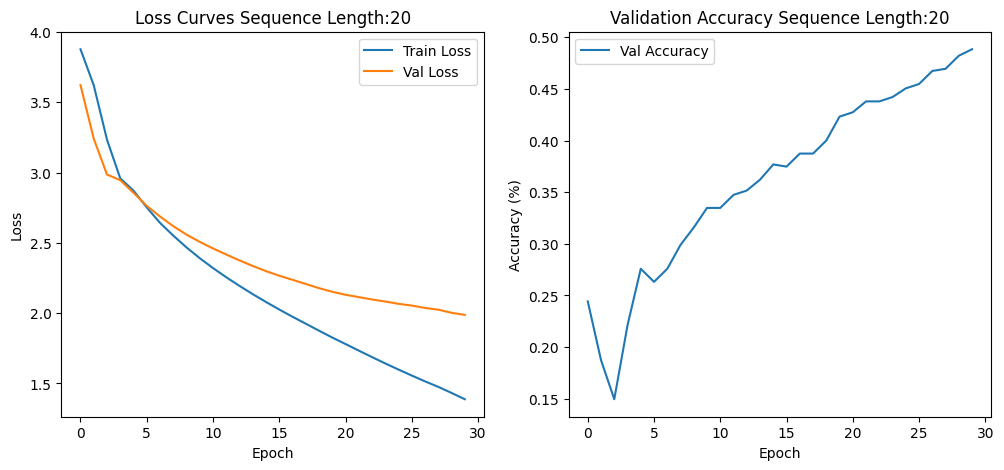

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─LSTM: 1-2                              [1, 20, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.63
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.36
Estimated Total Size (MB): 0.39
Epoch 0, Loss: 3.8519, Val Accuracy: 0.1691, Val Loss: 3.5961
Epoch 1, Loss: 3.5659, Val Accuracy: 0.1649, Val Loss: 3.2271
Epoch 2, Loss: 3.1552, Val Accuracy: 0.1522, Val Loss: 3.0281
Epoch 3, Loss: 2.9114, Val Accuracy: 0.1839, Val Loss: 2.9217
Epoch 4, Loss: 2.7732, Val Accuracy: 0.2135, Val Loss: 2.8294
Epoch 5, Loss: 2.6702, Val Accuracy: 0.2558, Val Loss: 2.7414
Epoch 6, Loss: 2.5776, Val Accuracy: 0

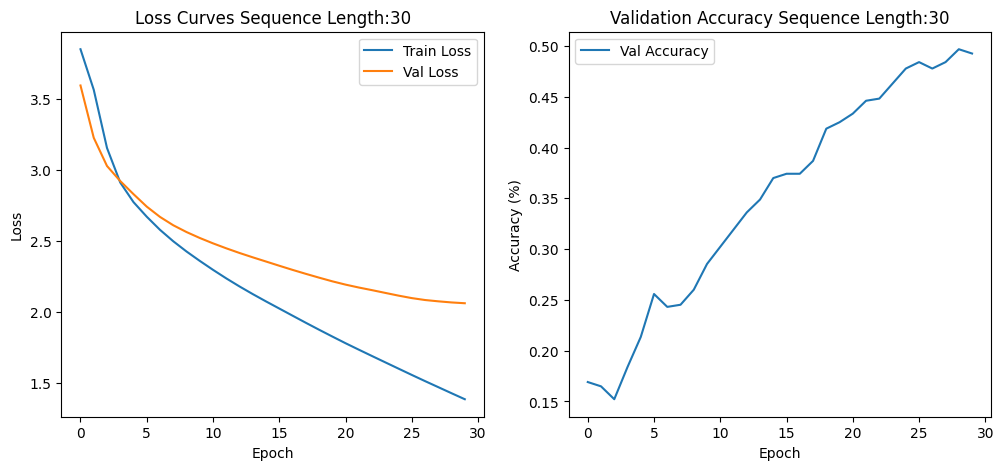

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─LSTM: 1-2                              [1, 20, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.63
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.36
Estimated Total Size (MB): 0.39


In [29]:
run("LSTM")

Epoch 0, Loss: 3.8608, Val Accuracy: 0.2432, Val Loss: 3.4401
Epoch 1, Loss: 3.4409, Val Accuracy: 0.2243, Val Loss: 2.9993
Epoch 2, Loss: 3.0092, Val Accuracy: 0.2285, Val Loss: 2.7829
Epoch 3, Loss: 2.8018, Val Accuracy: 0.3040, Val Loss: 2.6760
Epoch 4, Loss: 2.6767, Val Accuracy: 0.2830, Val Loss: 2.5930
Epoch 5, Loss: 2.5820, Val Accuracy: 0.3312, Val Loss: 2.4932
Epoch 6, Loss: 2.4696, Val Accuracy: 0.3585, Val Loss: 2.4014
Epoch 7, Loss: 2.3662, Val Accuracy: 0.3836, Val Loss: 2.3277
Epoch 8, Loss: 2.2827, Val Accuracy: 0.3878, Val Loss: 2.2678
Epoch 9, Loss: 2.2115, Val Accuracy: 0.4130, Val Loss: 2.2166
Epoch 10, Loss: 2.1441, Val Accuracy: 0.4403, Val Loss: 2.1722
Epoch 11, Loss: 2.0782, Val Accuracy: 0.4361, Val Loss: 2.1347
Epoch 12, Loss: 2.0155, Val Accuracy: 0.4444, Val Loss: 2.1031
Epoch 13, Loss: 1.9570, Val Accuracy: 0.4465, Val Loss: 2.0735
Epoch 14, Loss: 1.9004, Val Accuracy: 0.4675, Val Loss: 2.0427
Epoch 15, Loss: 1.8433, Val Accuracy: 0.4633, Val Loss: 2.0120
Ep

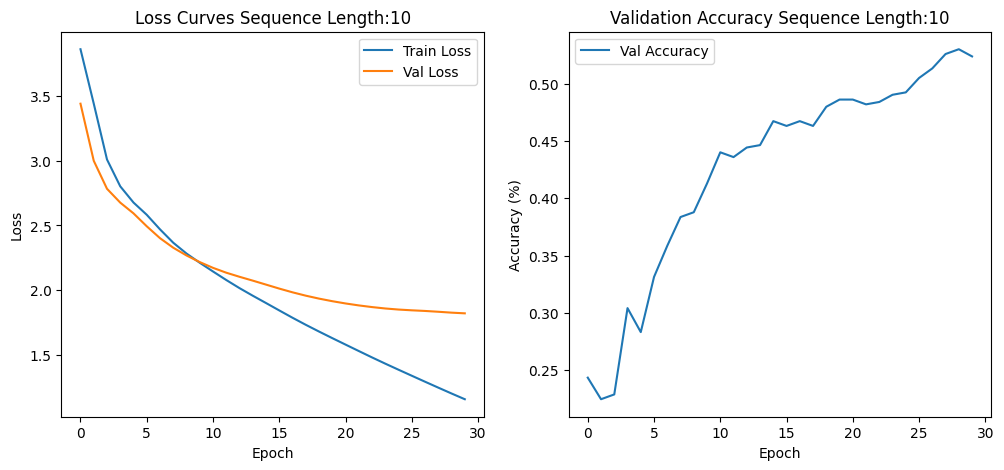

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─GRU: 1-2                               [1, 20, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.22
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.28
Estimated Total Size (MB): 0.31
Epoch 0, Loss: 3.8596, Val Accuracy: 0.1684, Val Loss: 3.4262
Epoch 1, Loss: 3.3918, Val Accuracy: 0.1600, Val Loss: 3.0217
Epoch 2, Loss: 2.9514, Val Accuracy: 0.2147, Val Loss: 2.8972
Epoch 3, Loss: 2.8062, Val Accuracy: 0.2842, Val Loss: 2.7977
Epoch 4, Loss: 2.6805, Val Accuracy: 0.2821, Val Loss: 2.7130
Epoch 5, Loss: 2.5604, Val Accuracy: 0.2737, Val Loss: 2.6406
Epoch 6, Loss: 2.4565, Val Accuracy: 0

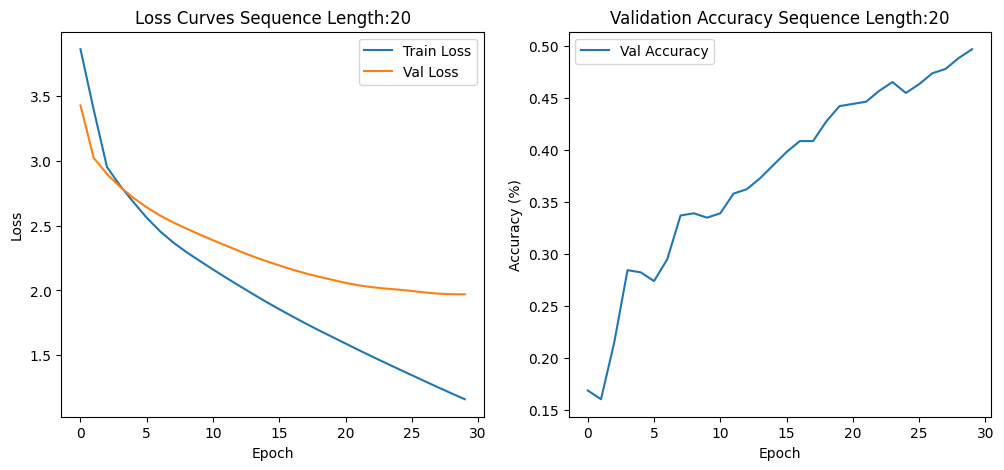

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─GRU: 1-2                               [1, 20, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.22
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.28
Estimated Total Size (MB): 0.31
Epoch 0, Loss: 3.8916, Val Accuracy: 0.1522, Val Loss: 3.4734
Epoch 1, Loss: 3.4370, Val Accuracy: 0.1628, Val Loss: 3.0889
Epoch 2, Loss: 2.9947, Val Accuracy: 0.1924, Val Loss: 2.9338
Epoch 3, Loss: 2.7879, Val Accuracy: 0.2114, Val Loss: 2.8180
Epoch 4, Loss: 2.6599, Val Accuracy: 0.2368, Val Loss: 2.7128
Epoch 5, Loss: 2.5414, Val Accuracy: 0.2410, Val Loss: 2.6268
Epoch 6, Loss: 2.4353, Val Accuracy: 0

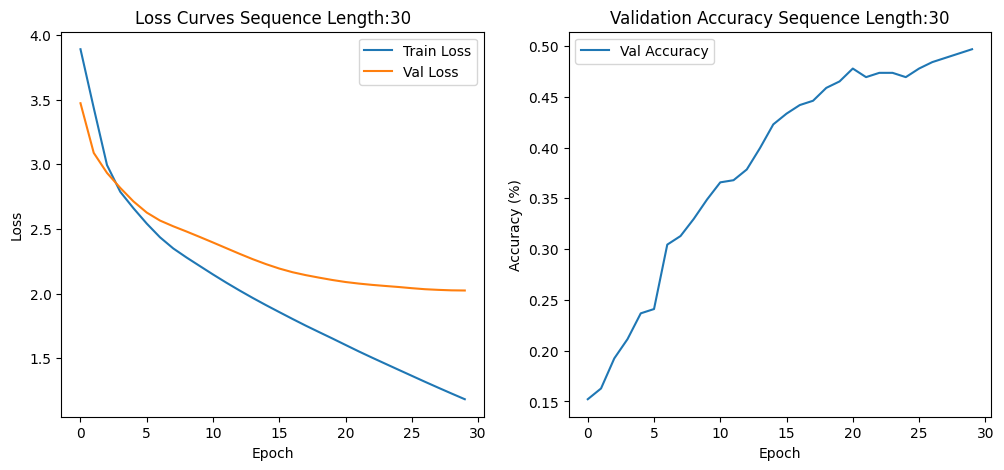

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─GRU: 1-2                               [1, 20, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.22
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.28
Estimated Total Size (MB): 0.31


In [30]:
run("GRU")